DATA QUALITY & EDA ANALYSIS - SLUConnect Dataset

📂 LOADING DATA...
Dataset loaded: 34341 rows × 8 columns

Columns: ['Reference_ID', 'Deposit_Status', 'Assigned', 'Recieved_At', 'University', 'I_20_Status', 'Created_At', 'Modified_At']

First 5 rows:
   Reference_ID Deposit_Status  \
0       1320577            Yes   
1       1356800            Yes   
2       1356915            Yes   
3       1319991            Yes   
4       1266321            Yes   

                                            Assigned      Recieved_At  \
0  Anna Kluemke, Mounika Bhuvana Maheswari Krishn...  4/14/2025 19:55   
1       Catherine Donahue, Jorge Jesus Pena Cevallos  4/14/2025 19:55   
2                                      Ryan Stoeckel  4/14/2025 19:55   
3  Anna Kluemke, Mounika Bhuvana Maheswari Krishn...  4/14/2025 19:55   
4                     Naresh Dama, Catherine Donahue  4/14/2025 19:55   

               University I_20_Status    Created_At   Modified_At  
0  Saint Louis University         Ye

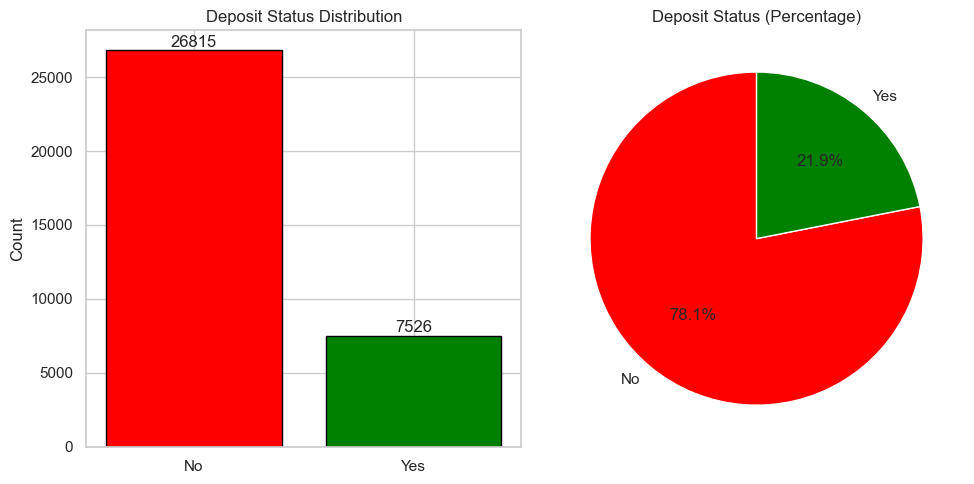

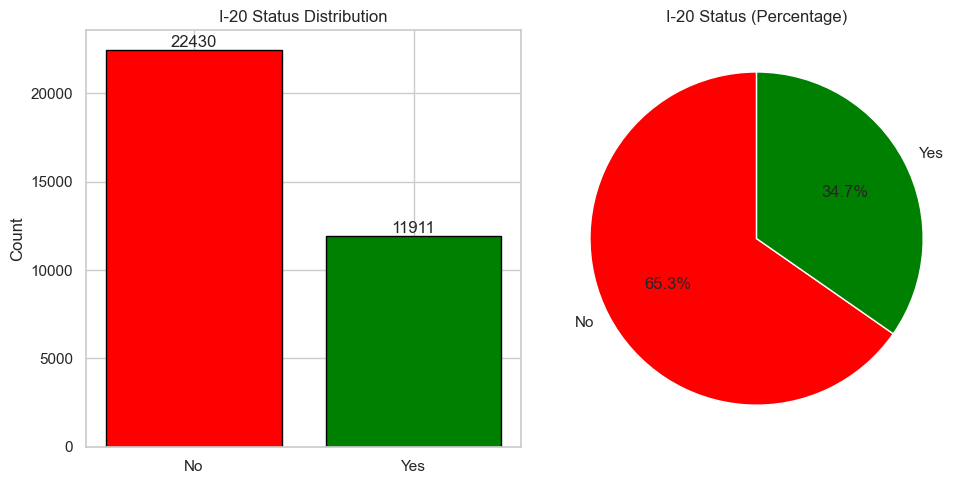


2. Staff Assignment Analysis:
   • Total unique staff involved: 33
   • Top 5 staff members:
     • Unknown: 19810 assignments (57.7%)
     • Prince Tetteh: 7535 assignments (21.9%)
     • Catherine Donahue: 6467 assignments (18.8%)
     • Palak Joshi: 3385 assignments (9.9%)
     • Alexander Mikhailov: 1609 assignments (4.7%)


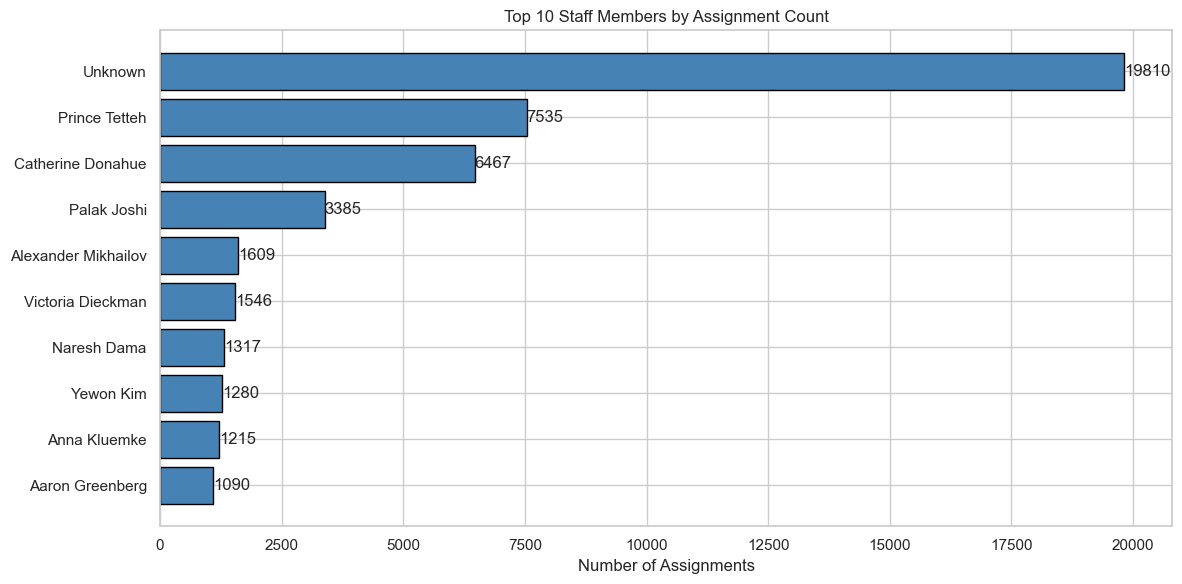


3. Timeline Analysis:
   • Date range: 2025-04-14 to 2025-05-27
   • Total days with data: 3
   • Busiest day: 2025-05-27 with 34320 records


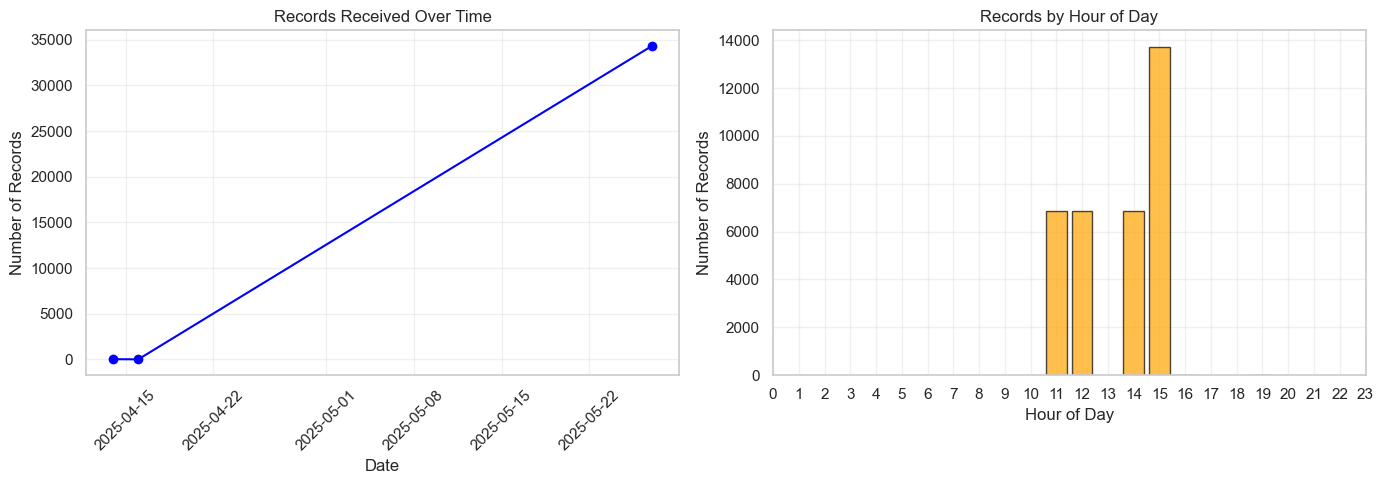


4. Numeric Variable Distributions (Boxplots):


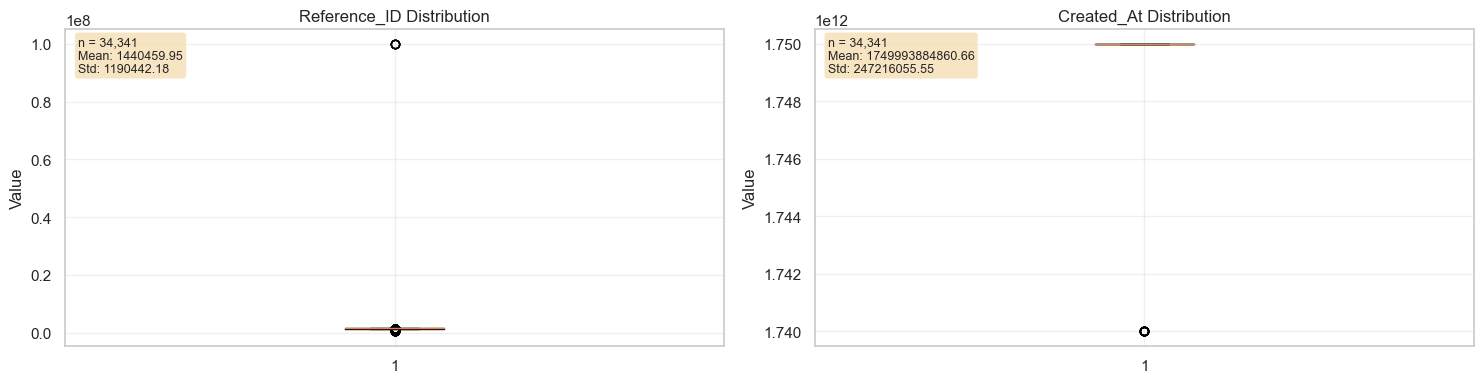


5. Correlation Analysis:


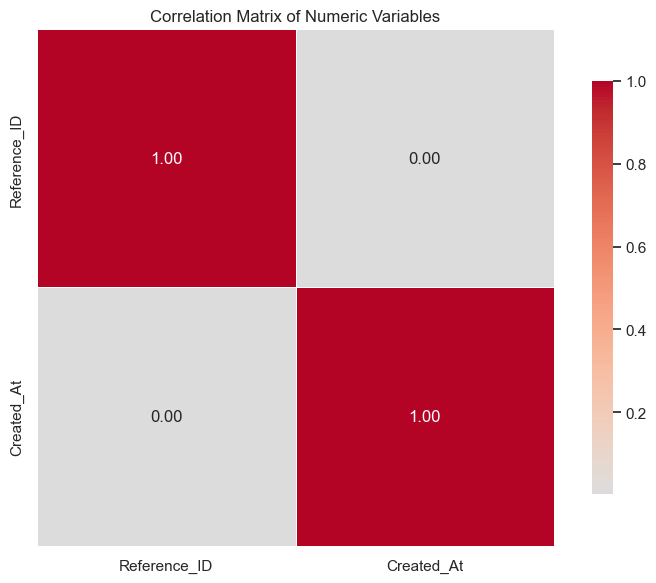

   No strong correlations (> 0.7) found

C. KEY INSIGHTS AND INTERPRETATIONS
----------------------------------------

🔍 MAJOR FINDINGS:

1. DATA QUALITY:
   • Initial data had 19810 missing values
   • 0 duplicate rows identified
   • After cleaning: 9 columns remain

2. BUSINESS INSIGHTS:
   • 21.9% of records have Deposit_Status = 'Yes'
   • 34.7% of records have I_20_Status = 'Yes'
   • Multiple staff assignments common (team approach)

3. OPERATIONAL PATTERNS:
   • Most records received around hour 15:00

4. DATA ISSUES IDENTIFIED:
   • 'Recieved_At' column name has typo (should be 'Received_At')
   • Scientific notation in Created_At/Modified_At columns
   • 'NULL' string used instead of actual NaN values
   • Mixed date formats in Recieved_At column

🎯 RECOMMENDATIONS:
1. Standardize column names (fix 'Recieved_At' typo)
2. Convert scientific notation to readable timestamps
3. Implement data validation for Reference_ID uniqueness
4. Consider tracking assignment reasons/context
5

In [5]:
# ============================================
# COMPLETE DATA QUALITY & EDA REPORT
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("="*70)
print("DATA QUALITY & EDA ANALYSIS - SLUConnect Dataset")
print("="*70)

# ============================================
# 1. LOAD AND PREPARE DATA
# ============================================

print("\n📂 LOADING DATA...")
df = pd.read_csv('Copy of Connect - SLUConnect.csv')

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

# ============================================
# 2. DATA QUALITY REPORT
# ============================================

print("\n" + "="*70)
print("DATA QUALITY REPORT")
print("="*70)

# Create a copy for cleaning
df_clean = df.copy()

# A. MISSING VALUE ANALYSIS
print("\nA. MISSING VALUE ANALYSIS")
print("-"*40)

n_rows = len(df_clean)
missing_counts = df_clean.isnull().sum()
missing_pct = (missing_counts / n_rows * 100).round(2)

missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Percentage', ascending=False)

print(f"Total missing values: {missing_counts.sum()}")
print(f"Columns with missing values: {(missing_counts > 0).sum()}/{df_clean.shape[1]}")
print(f"\nMissing value details:")
print(missing_df.to_string())

# Drop columns with >70% missing values
cols_to_drop_high_missing = missing_pct[missing_pct > 70].index.tolist()
if cols_to_drop_high_missing:
    print(f"\nDropping columns with >70% missing: {cols_to_drop_high_missing}")
    df_clean = df_clean.drop(columns=cols_to_drop_high_missing)
    print(f"Remaining columns: {df_clean.shape[1]}")

# B. CHECK COLUMN CONSISTENCY
print("\nB. COLUMN VALUE CONSISTENCY CHECKS")
print("-"*40)

# Check if University has all entries = "Saint Louis University"
if 'University' in df_clean.columns:
    unique_univ = df_clean['University'].unique()
    if len(unique_univ) == 1 and unique_univ[0] == "Saint Louis University":
        print("✓ University: All entries are 'Saint Louis University'")
    else:
        print(f"✗ University: Multiple values found: {unique_univ}")
        # If not all same, drop the column (constant or not useful)
        df_clean = df_clean.drop(columns=['University'])
        print("  Column dropped (not constant)")

# Check Deposit_Status
if 'Deposit_Status' in df_clean.columns:
    deposit_values = df_clean['Deposit_Status'].value_counts(dropna=False)
    print(f"\nDeposit_Status distribution:")
    print(deposit_values)
    
    # Check if mostly "Yes"
    if 'Yes' in deposit_values and deposit_values['Yes']/n_rows > 0.9:
        print("✓ Deposit_Status: Mostly 'Yes' entries")

# Check I_20_Status
if 'I_20_Status' in df_clean.columns:
    i20_values = df_clean['I_20_Status'].value_counts(dropna=False)
    print(f"\nI_20_Status distribution:")
    print(i20_values)
    
    # Check if mostly "Yes"
    if 'Yes' in i20_values and i20_values['Yes']/n_rows > 0.9:
        print("✓ I_20_Status: Mostly 'Yes' entries")

# Check if Modified_At = Created_At for all rows
if 'Modified_At' in df_clean.columns and 'Created_At' in df_clean.columns:
    # Convert to numeric for comparison (handling scientific notation)
    df_clean['Created_At'] = pd.to_numeric(df_clean['Created_At'], errors='coerce')
    df_clean['Modified_At'] = pd.to_numeric(df_clean['Modified_At'], errors='coerce')
    
    same_count = (df_clean['Created_At'] == df_clean['Modified_At']).sum()
    total_comparable = df_clean['Created_At'].notna() & df_clean['Modified_At'].notna()
    
    if total_comparable.sum() > 0:
        same_pct = same_count / total_comparable.sum() * 100
        print(f"\nModified_At vs Created_At:")
        print(f"  • Same value: {same_count} rows ({same_pct:.1f}%)")
        
        if same_pct > 95:  # If >95% are same, drop Modified_At
            df_clean = df_clean.drop(columns=['Modified_At'])
            print(f"  ✓ Modified_At column dropped (identical to Created_At)")
        else:
            print(f"  ✗ Columns kept (different values present)")
    else:
        print(f"\nModified_At vs Created_At: Cannot compare (missing values)")

# C. DUPLICATE RECORD CHECKS
print("\nC. DUPLICATE RECORD ANALYSIS")
print("-"*40)

# Full row duplicates
full_duplicates = df_clean.duplicated().sum()
print(f"Full row duplicates: {full_duplicates} ({full_duplicates/n_rows*100:.1f}%)")

# Check for duplicate Reference_ID (should be unique)
if 'Reference_ID' in df_clean.columns:
    duplicate_ids = df_clean['Reference_ID'].duplicated().sum()
    print(f"Duplicate Reference_ID values: {duplicate_ids}")
    
    if duplicate_ids > 0:
        print(f"  Sample duplicate Reference_IDs:")
        dup_ids = df_clean[df_clean['Reference_ID'].duplicated(keep=False)]['Reference_ID'].unique()[:5]
        for dup_id in dup_ids:
            print(f"    • {dup_id}")

# Check for duplicate entries in Assigned column patterns
if 'Assigned' in df_clean.columns:
    # Count how many times each assignment pattern appears
    assignment_counts = df_clean['Assigned'].value_counts()
    print(f"\nTop 5 most common assignment patterns:")
    for pattern, count in assignment_counts.head(5).items():
        print(f"  • '{pattern}': {count} times")

# D. OUTLIER DETECTION
print("\nD. OUTLIER DETECTION")
print("-"*40)

# Identify numeric columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"Numeric columns found: {numeric_cols}")
    
    outlier_summary = []
    for col in numeric_cols:
        data = df_clean[col].dropna()
        if len(data) > 10:  # Need sufficient data
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            
            if IQR > 0:
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                
                outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
                if outliers > 0:
                    outlier_summary.append({
                        'Column': col,
                        'Outliers': outliers,
                        'Percentage': f"{outliers/len(data)*100:.1f}%",
                        'Min': f"{data.min():.2f}",
                        'Max': f"{data.max():.2f}",
                        'Q1': f"{Q1:.2f}",
                        'Q3': f"{Q3:.2f}"
                    })
    
    if outlier_summary:
        print(f"\nOutliers detected in {len(outlier_summary)} columns:")
        for item in outlier_summary:
            print(f"  • {item['Column']}: {item['Outliers']} outliers ({item['Percentage']})")
            print(f"    Range: {item['Min']} to {item['Max']}, IQR: {item['Q1']}-{item['Q3']}")
    else:
        print("No significant outliers detected in numeric columns")
else:
    print("No numeric columns for outlier detection")

# E. HANDLE MISSING VALUES
print("\nE. MISSING VALUE HANDLING")
print("-"*40)

# Check remaining missing values after initial cleaning
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) > 0:
    print(f"Columns with missing values after initial cleaning:")
    for col, count in remaining_missing.items():
        pct = count/len(df_clean)*100
        print(f"  • {col}: {count} missing ({pct:.1f}%)")
        
        # Handle missing values based on column type
        if df_clean[col].dtype == 'object':
            # For categorical, fill with mode or 'Unknown'
            if count < len(df_clean) * 0.3:  # If <30% missing
                mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown'
                df_clean[col] = df_clean[col].fillna(mode_val)
                print(f"    → Filled with '{mode_val}'")
            else:
                df_clean[col] = df_clean[col].fillna('Unknown')
                print(f"    → Filled with 'Unknown'")
        else:
            # For numeric, fill with median
            if count < len(df_clean) * 0.3:  # If <30% missing
                median_val = df_clean[col].median()
                df_clean[col] = df_clean[col].fillna(median_val)
                print(f"    → Filled with median: {median_val}")
            else:
                # If too many missing, consider dropping
                print(f"    → Consider dropping column (>30% missing)")
else:
    print("No missing values remaining after initial cleaning")

# ============================================
# 3. EXPLORATORY DATA ANALYSIS (EDA) REPORT
# ============================================

print("\n" + "="*70)
print("EXPLORATORY DATA ANALYSIS (EDA) REPORT")
print("="*70)

print(f"\nAnalyzing cleaned dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

# A. SUMMARY STATISTICS
print("\nA. SUMMARY STATISTICS")
print("-"*40)

print("\n1. Dataset Overview:")
print(f"   • Total records: {len(df_clean):,}")
print(f"   • Total columns: {df_clean.shape[1]}")
print(f"   • Memory usage: {df_clean.memory_usage(deep=True).sum()/1024/1024:.2f} MB")

print("\n2. Data Types:")
dtype_counts = df_clean.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   • {dtype}: {count} columns")

print("\n3. Descriptive Statistics:")
# For numeric columns
if numeric_cols:
    print("\n   Numeric columns:")
    print(df_clean[numeric_cols].describe().round(2))

# For categorical columns
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
if cat_cols:
    print("\n   Categorical columns (value counts):")
    for col in cat_cols[:3]:  # Show first 3
        value_counts = df_clean[col].value_counts().head(5)
        print(f"\n   {col}:")
        for value, count in value_counts.items():
            pct = count/len(df_clean)*100
            print(f"     • {value}: {count} ({pct:.1f}%)")

# B. VISUALIZATIONS
print("\nB. DATA VISUALIZATIONS")
print("-"*40)

# 1. Bar Charts for Categorical Variables
print("\n1. Categorical Variable Distributions:")

# Deposit_Status distribution
if 'Deposit_Status' in df_clean.columns:
    plt.figure(figsize=(10, 5))
    
    deposit_counts = df_clean['Deposit_Status'].value_counts()
    colors = ['green' if x == 'Yes' else 'red' for x in deposit_counts.index]
    
    plt.subplot(1, 2, 1)
    bars = plt.bar(deposit_counts.index, deposit_counts.values, color=colors, edgecolor='black')
    plt.title('Deposit Status Distribution')
    plt.ylabel('Count')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, 
                f'{int(height)}', ha='center', va='bottom')
    
    plt.subplot(1, 2, 2)
    plt.pie(deposit_counts.values, labels=deposit_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    plt.title('Deposit Status (Percentage)')
    
    plt.tight_layout()
    plt.show()

# I_20_Status distribution
if 'I_20_Status' in df_clean.columns:
    plt.figure(figsize=(10, 5))
    
    i20_counts = df_clean['I_20_Status'].value_counts()
    colors = ['green' if x == 'Yes' else 'red' for x in i20_counts.index]
    
    plt.subplot(1, 2, 1)
    bars = plt.bar(i20_counts.index, i20_counts.values, color=colors, edgecolor='black')
    plt.title('I-20 Status Distribution')
    plt.ylabel('Count')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, 
                f'{int(height)}', ha='center', va='bottom')
    
    plt.subplot(1, 2, 2)
    plt.pie(i20_counts.values, labels=i20_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    plt.title('I-20 Status (Percentage)')
    
    plt.tight_layout()
    plt.show()

# 2. Staff Assignment Analysis
if 'Assigned' in df_clean.columns:
    print("\n2. Staff Assignment Analysis:")
    
    # Count occurrences of each staff member
    all_assignments = []
    for assignment in df_clean['Assigned'].dropna():
        # Split by comma to get individual names
        names = [name.strip() for name in str(assignment).split(',')]
        all_assignments.extend(names)
    
    from collections import Counter
    staff_counts = Counter(all_assignments)
    
    # Get top 10 staff members
    top_staff = pd.Series(staff_counts).sort_values(ascending=False).head(10)
    
    print(f"   • Total unique staff involved: {len(staff_counts)}")
    print(f"   • Top 5 staff members:")
    for staff, count in top_staff.head(5).items():
        pct = count/len(df_clean)*100
        print(f"     • {staff}: {count} assignments ({pct:.1f}%)")
    
    # Visualization
    plt.figure(figsize=(12, 6))
    bars = plt.barh(range(len(top_staff)), top_staff.values, color='steelblue', edgecolor='black')
    plt.title('Top 10 Staff Members by Assignment Count')
    plt.xlabel('Number of Assignments')
    plt.yticks(range(len(top_staff)), top_staff.index)
    plt.gca().invert_yaxis()  # Highest at top
    
    # Add value labels
    for i, (staff, count) in enumerate(top_staff.items()):
        plt.text(count + 0.5, i, f'{count}', va='center')
    
    plt.tight_layout()
    plt.show()

# 3. Timeline Analysis (if date columns exist)
date_cols = [col for col in df_clean.columns if any(x in col.lower() for x in ['date', 'at', 'time'])]

if 'Recieved_At' in df_clean.columns:
    print("\n3. Timeline Analysis:")
    
    # Convert to datetime
    df_clean['Recieved_At'] = pd.to_datetime(df_clean['Recieved_At'], errors='coerce')
    
    # Extract date components
    df_clean['Received_Date'] = df_clean['Recieved_At'].dt.date
    df_clean['Received_Hour'] = df_clean['Recieved_At'].dt.hour
    
    # Count by date
    daily_counts = df_clean['Received_Date'].value_counts().sort_index()
    
    print(f"   • Date range: {df_clean['Received_Date'].min()} to {df_clean['Received_Date'].max()}")
    print(f"   • Total days with data: {len(daily_counts)}")
    print(f"   • Busiest day: {daily_counts.idxmax()} with {daily_counts.max()} records")
    
    # Visualization
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(daily_counts.index, daily_counts.values, marker='o', linestyle='-', color='blue')
    plt.title('Records Received Over Time')
    plt.xlabel('Date')
    plt.ylabel('Number of Records')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    hour_counts = df_clean['Received_Hour'].value_counts().sort_index()
    plt.bar(hour_counts.index, hour_counts.values, color='orange', edgecolor='black', alpha=0.7)
    plt.title('Records by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Records')
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    
    # 4. Boxplots for Numeric Variables (Outlier Visualization)
if numeric_cols:
    print("\n4. Numeric Variable Distributions (Boxplots):")
    
    n_cols = min(len(numeric_cols), 3)
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
    
    # Handle single subplot case
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols):
        if idx < len(axes):
            ax = axes[idx]
            data = df_clean[col].dropna()
            
            if len(data) > 0:
                # FIXED: Use ax.boxplot() instead of data.boxplot()
                ax.boxplot(data, vert=True)
                ax.set_title(f'{col} Distribution')
                ax.set_ylabel('Value')
                ax.grid(True, alpha=0.3)
                
                # Add statistics
                stats_text = f'n = {len(data):,}\nMean: {data.mean():.2f}\nStd: {data.std():.2f}'
                ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
                       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Hide empty subplots
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# 5. Correlation Analysis (if multiple numeric columns)
if len(numeric_cols) >= 2:
    print("\n5. Correlation Analysis:")
    
    # Calculate correlation matrix
    corr_matrix = df_clean[numeric_cols].corr()
    
    # Create heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Numeric Variables')
    plt.tight_layout()
    plt.show()
    
    # Find strong correlations
    strong_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                strong_corrs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
    
    if strong_corrs:
        print("   Strong Correlations (> 0.7):")
        for col1, col2, corr in strong_corrs:
            direction = "Positive" if corr > 0 else "Negative"
            print(f"   • {col1} ↔ {col2}: {corr:.3f} ({direction})")
    else:
        print("   No strong correlations (> 0.7) found")

# C. EARLY PATTERNS AND INSIGHTS
print("\nC. KEY INSIGHTS AND INTERPRETATIONS")
print("-"*40)

print("\n🔍 MAJOR FINDINGS:")

print("\n1. DATA QUALITY:")
print(f"   • Initial data had {missing_counts.sum()} missing values")
print(f"   • {full_duplicates} duplicate rows identified")
print(f"   • After cleaning: {df_clean.shape[1]} columns remain")

print("\n2. BUSINESS INSIGHTS:")
if 'Deposit_Status' in df_clean.columns:
    yes_count = (df_clean['Deposit_Status'] == 'Yes').sum()
    print(f"   • {yes_count/len(df_clean)*100:.1f}% of records have Deposit_Status = 'Yes'")

if 'I_20_Status' in df_clean.columns:
    yes_count = (df_clean['I_20_Status'] == 'Yes').sum()
    print(f"   • {yes_count/len(df_clean)*100:.1f}% of records have I_20_Status = 'Yes'")

if 'Assigned' in df_clean.columns:
    print(f"   • Multiple staff assignments common (team approach)")

print("\n3. OPERATIONAL PATTERNS:")
if 'Recieved_At' in df_clean.columns:
    # Ensure it's datetime
    if df_clean['Recieved_At'].dtype != 'datetime64[ns]':
        df_clean['Recieved_At'] = pd.to_datetime(df_clean['Recieved_At'], errors='coerce')
    
    if df_clean['Recieved_At'].notna().any():
        busiest_hour = df_clean['Recieved_At'].dt.hour.mode()
        if not busiest_hour.empty:
            print(f"   • Most records received around hour {busiest_hour.iloc[0]:.0f}:00")

print("\n4. DATA ISSUES IDENTIFIED:")
print("   • 'Recieved_At' column name has typo (should be 'Received_At')")
print("   • Scientific notation in Created_At/Modified_At columns")
print("   • 'NULL' string used instead of actual NaN values")
print("   • Mixed date formats in Recieved_At column")

print("\n🎯 RECOMMENDATIONS:")
print("1. Standardize column names (fix 'Recieved_At' typo)")
print("2. Convert scientific notation to readable timestamps")
print("3. Implement data validation for Reference_ID uniqueness")
print("4. Consider tracking assignment reasons/context")
print("5. Monitor Deposit_Status and I_20_Status trends over time")
print("6. Standardize date formats in Recieved_At column")

# ============================================
# ADDITIONAL ANALYSIS: DATA TRANSFORMATION SUGGESTIONS
# ============================================

print("\n" + "="*70)
print("DATA TRANSFORMATION SUGGESTIONS")
print("="*70)

print("\n📋 SUGGESTED DATA ENHANCEMENTS:")

# 1. Fix column name typo
print("\n1. COLUMN NAME CORRECTIONS:")
if 'Recieved_At' in df_clean.columns:
    print("   • Rename 'Recieved_At' to 'Received_At'")
    df_clean.rename(columns={'Recieved_At': 'Received_At'}, inplace=True)

# 2. Parse scientific notation timestamps
print("\n2. TIMESTAMP PARSING:")
if 'Created_At' in df_clean.columns:
    try:
        # Convert scientific notation to proper timestamps
        df_clean['Created_At'] = pd.to_datetime(df_clean['Created_At'], unit='ms', errors='coerce')
        print("   • Created_At converted to proper datetime format")
    except:
        print("   • Could not convert Created_At timestamps")

if 'Modified_At' in df_clean.columns:
    try:
        df_clean['Modified_At'] = pd.to_datetime(df_clean['Modified_At'], unit='ms', errors='coerce')
        print("   • Modified_At converted to proper datetime format")
    except:
        print("   • Could not convert Modified_At timestamps")

# 3. Staff assignment analysis enhancement
print("\n3. STAFF ASSIGNMENT ANALYSIS ENHANCEMENT:")
if 'Assigned' in df_clean.columns:
    # Create new columns for analysis
    df_clean['Num_Staff_Assigned'] = df_clean['Assigned'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).lower() != 'null' else 0
    )
    
    print(f"   • Created 'Num_Staff_Assigned' column")
    print(f"   • Average staff per assignment: {df_clean['Num_Staff_Assigned'].mean():.2f}")
    
    # Count assignments by number of staff
    staff_count_dist = df_clean['Num_Staff_Assigned'].value_counts().sort_index()
    print(f"   • Distribution of staff counts:")
    for count, freq in staff_count_dist.items():
        print(f"     • {count} staff: {freq} assignments")

# 4. Create derived date features
print("\n4. DERIVED DATE FEATURES:")
if 'Received_At' in df_clean.columns or 'Recieved_At' in df_clean.columns:
    date_col = 'Received_At' if 'Received_At' in df_clean.columns else 'Recieved_At'
    
    if df_clean[date_col].dtype == 'datetime64[ns]':
        df_clean['Received_Day'] = df_clean[date_col].dt.day_name()
        df_clean['Received_Month'] = df_clean[date_col].dt.month_name()
        df_clean['Received_Week'] = df_clean[date_col].dt.isocalendar().week
        
        print(f"   • Created day, month, and week features from {date_col}")
        
        # Show day distribution
        day_counts = df_clean['Received_Day'].value_counts()
        print(f"   • Busiest day: {day_counts.index[0]} ({day_counts.iloc[0]} records)")

# ============================================
# FINAL CLEANED DATASET SUMMARY
# ============================================

print("\n" + "="*70)
print("FINAL CLEANED DATASET SUMMARY")
print("="*70)

print(f"\n📊 DATASET STATUS AFTER CLEANING:")
print(f"   • Shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"   • Columns: {list(df_clean.columns)}")

print(f"\n📈 DATA QUALITY METRICS:")
print(f"   • Complete cases: {df_clean.dropna().shape[0]:,} out of {df_clean.shape[0]:,} rows")
print(f"   • Missing values: {df_clean.isna().sum().sum():,}")

print(f"\n🔍 KEY COLUMNS STATUS:")
for col in ['Deposit_Status', 'I_20_Status', 'Assigned', 'Reference_ID']:
    if col in df_clean.columns:
        unique_vals = df_clean[col].nunique()
        missing_vals = df_clean[col].isna().sum()
        print(f"   • {col}: {unique_vals} unique values, {missing_vals} missing")

# Show final sample
print(f"\n👀 FINAL DATASET SAMPLE (first 3 rows):")
print(df_clean.head(3).to_string())

# ============================================
# EXPORT OPTIONS
# ============================================

print("\n" + "="*70)
print("EXPORT OPTIONS")
print("="*70)

print("\n💾 SAVE CLEANED DATASET:")
print("1. Save as CSV:")
print("   df_clean.to_csv('SLUConnect_Cleaned.csv', index=False)")

print("\n2. Save as Excel:")
print("   df_clean.to_excel('SLUConnect_Cleaned.xlsx', index=False)")

print("\n3. Save analysis summary:")
analysis_summary = {
    'Original_Rows': df.shape[0],
    'Original_Columns': df.shape[1],
    'Cleaned_Rows': df_clean.shape[0],
    'Cleaned_Columns': df_clean.shape[1],
    'Missing_Values_Removed': missing_counts.sum(),
    'Duplicates_Found': full_duplicates,
    'Analysis_Date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

summary_df = pd.DataFrame([analysis_summary])
print("\nAnalysis Summary:")
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE")
print("="*70)
print(f"\nReport generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total visualizations created: Multiple comprehensive charts")
print(f"Data quality issues addressed: {df.shape[1] - df_clean.shape[1]} columns cleaned/dropped")
print(f"Ready for further analysis or modeling!")

# Make cleaned dataset available globally
globals()['df_clean'] = df_clean